# Examen IB
## Parte 1 — Carga y preprocesamiento
### Aubertin Ochoa
### 1. Instalación de librerías

In [ ]:
# Instalación de dependencias

!pip install pandas
!pip install numpy
!pip install nltk
!pip install scikit-learn
!pip install sentence-transformers
!pip install matplotlib

In [1]:
# Importar librerias
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LabP5E004\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LabP5E004\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Cargar el Dataset
movies = pd.read_csv("data//rotten_tomatoes_movies.csv")
reviews = pd.read_csv("data//rotten_tomatoes_critic_reviews.csv")

print(movies.shape)
print(reviews.shape)

(17712, 22)
(1130017, 8)


In [3]:
# Union de los 2 datasets para trabajar mas facil
df = pd.merge(
    reviews,
    movies,
    on='rotten_tomatoes_link',
    how='left'
)

In [4]:
df.head()

,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content,movie_title,movie_info,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology...,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiff...",Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,With a top-notch cast and dazzling special eff...,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0
3,m/0814255,Ben McEachen,False,Sunday Mail (Australia),Fresh,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0
4,m/0814255,Ethan Alter,True,Hollywood Reporter,Rotten,NaN,2010-02-10,What's really lacking in The Lightning Thief i...,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43.0,73.0,76.0


In [5]:
df.columns

Index(['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name',
       'review_type', 'review_score', 'review_date', 'review_content',
       'movie_title', 'movie_info', 'critics_consensus', 'content_rating',
       'genres', 'directors', 'authors', 'actors', 'original_release_date',
       'streaming_release_date', 'runtime', 'production_company',
       'tomatometer_status', 'tomatometer_rating', 'tomatometer_count',
       'audience_status', 'audience_rating', 'audience_count',
       'tomatometer_top_critics_count', 'tomatometer_fresh_critics_count',
       'tomatometer_rotten_critics_count'],
      dtype='object')

In [6]:
df['text'] = (
    df['movie_title'].fillna('') + ' ' +
    df['genres'].fillna('') + ' ' +
    df['critics_consensus'].fillna('') + ' ' +
    df['review_content'].fillna('')
)

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    # minúsculas
    text = text.lower()

    # eliminar puntuación
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # eliminar espacios extra
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenización
    words = text.split()

    # eliminar stopwords + lematización
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

In [8]:
df['processed_text'] = df['text'].apply(preprocess)

In [9]:
df[['text', 'processed_text']].head()

,text,processed_text
0,Percy Jackson & the Olympians: The Lightning T...,percy jackson olympian lightning thief action ...
1,Percy Jackson & the Olympians: The Lightning T...,percy jackson olympian lightning thief action ...
2,Percy Jackson & the Olympians: The Lightning T...,percy jackson olympian lightning thief action ...
3,Percy Jackson & the Olympians: The Lightning T...,percy jackson olympian lightning thief action ...
4,Percy Jackson & the Olympians: The Lightning T...,percy jackson olympian lightning thief action ...


In [10]:
df['review_content'].head(10)

0    A fantasy adventure that fuses Greek mythology...
1    Uma Thurman as Medusa, the gorgon with a coiff...
2    With a top-notch cast and dazzling special eff...
3    Whether audiences will get behind The Lightnin...
4    What's really lacking in The Lightning Thief i...
5    It's more a list of ingredients than a movie-m...
6    Harry Potter knockoffs don't come more transpa...
7    Percy Jackson isn't a great movie, but it's a ...
8                           Fun, brisk and imaginative
9    Crammed with dragons, set-destroying fights an...
Name: review_content, dtype: object

In [11]:
pd.set_option('display.max_colwidth', None)

df[['movie_title', 'review_content']].head(10)

,movie_title,review_content
0,Percy Jackson & the Olympians: The Lightning Thief,A fantasy adventure that fuses Greek mythology to contemporary American places and values. Anyone around 15 (give or take a couple of years) will thrill to the visual spectacle
1,Percy Jackson & the Olympians: The Lightning Thief,"Uma Thurman as Medusa, the gorgon with a coiffure of writhing snakes and stone-inducing hypnotic gaze is one of the highlights of this bewitching fantasy"
2,Percy Jackson & the Olympians: The Lightning Thief,"With a top-notch cast and dazzling special effects, this will tide the teens over until the next Harry Potter instalment."
3,Percy Jackson & the Olympians: The Lightning Thief,"Whether audiences will get behind The Lightning Thief is hard to predict. Overall, it's an entertaining introduction to a promising new world -- but will the consuming shadow of Potter be too big to break free of?"
4,Percy Jackson & the Olympians: The Lightning Thief,"What's really lacking in The Lightning Thief is a genuine sense of wonder, the same thing that brings viewers back to Hogwarts over and over again."
5,Percy Jackson & the Olympians: The Lightning Thief,It's more a list of ingredients than a movie-magic potion to enjoy from start to finish.
6,Percy Jackson & the Olympians: The Lightning Thief,Harry Potter knockoffs don't come more transparent and slapdash than this wannabe-franchise jumpstarter directed by Chris Columbus.
7,Percy Jackson & the Olympians: The Lightning Thief,"Percy Jackson isn't a great movie, but it's a good one, trotting out kernels of Greek mythology like so many Disney Channel references."
8,Percy Jackson & the Olympians: The Lightning Thief,"Fun, brisk and imaginative"
9,Percy Jackson & the Olympians: The Lightning Thief,"Crammed with dragons, set-destroying fights and things exploding, [Columbus] squeezes in a few well-meaning pause breaks about friendship and absent fathers before swiftly moving on to the next pyrotechnics display."


# Parte 2 — Generación de embeddings

Para representar los documentos se utilizó el modelo
'all-MiniLM-L6-v2' de Sentence Transformers.

Este modelo genera representaciones vectoriales densas capaces de capturar relaciones semánticas entre documentos y consultas.

Cada documento fue transformado en un embedding de alta dimensionalidad, permitiendo posteriormente calcular similitud semántica mediante similitud coseno.

In [12]:
from sentence_transformers import SentenceTransformer

In [13]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Reducí el tamaño ya que era gigantesco y en las compus del lab se demoraba demasiado.  
Lo reducí a 5000.

In [14]:
df = df.sample(5000, random_state=42)

In [15]:
document_embeddings = model.encode(
    df['processed_text'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

In [16]:
document_embeddings.shape

(5000, 384)

In [24]:
import numpy as np

np.save("document_embeddings.npy", document_embeddings)

# Parte 3

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

In [18]:
def search(query, top_k=5):

    processed_query = preprocess(query)

    query_embedding = model.encode([processed_query])

    similarities = cosine_similarity(
        query_embedding,
        document_embeddings
    )[0]

    top_indices = similarities.argsort()[::-1][:top_k]

    results = []

    for rank, idx in enumerate(top_indices, start=1):

        review_text = str(df.iloc[idx]['review_content'])

        results.append({
            'Ranking': rank,
            'Document_ID': idx,
            'Movie_Title': df.iloc[idx]['movie_title'],
            'Similarity': round(similarities[idx], 4),
            'Review_Fragment': review_text[:200]
        })

    return pd.DataFrame(results)

In [19]:
query = "science fiction movie with advanced technology"

search(query)

,Ranking,Document_ID,Movie_Title,Similarity,Review_Fragment
0,1,1209,RocketMan,0.5187,nan
1,2,785,Beyond the Gates,0.5027,"A film born into the wrong decade, Beyond the Gates has a very late eighties / early nineties vibe to it. It's disarmingly charming."
2,3,2400,Back to the Future,0.4959,"Back to the Future is one of the best popcorn movies ever made. It's ingenuity, time-traveling twist ups and wonderfully vibrant characters resonate in ways few films ever achieve."
3,4,1298,Sidekick,0.4852,One of the best superhero films I've ever seen...
4,5,1504,The Conversation,0.4832,A fantastic reminder of why 70s Hollywood is so often the benchmark for modern moviedom to aspire to.


# Parte 4 — Benchmark de consultas

In [20]:
queries = [
    "science fiction movie with advanced technology",
    "romantic story with emotional relationships",
    "action movie with intense fight scenes",
    "horror film that creates fear and suspense",
    "visually impressive movie with weak storyline",
    "emotionally moving performance by the lead actor",
    "predictable plot but entertaining experience",
    "movie praised by critics but unpopular with audiences"
]

In [21]:
all_results = {}

for i, query in enumerate(queries, start=1):

    print(f"\n================ Q{i} ================\n")
    print("Query:", query)

    results = search(query, top_k=5)

    display(results)

    all_results[f"Q{i}"] = results


================ Q1 ================

Query: science fiction movie with advanced technology


,Ranking,Document_ID,Movie_Title,Similarity,Review_Fragment
0,1,1209,RocketMan,0.5187,nan
1,2,785,Beyond the Gates,0.5027,"A film born into the wrong decade, Beyond the Gates has a very late eighties / early nineties vibe to it. It's disarmingly charming."
2,3,2400,Back to the Future,0.4959,"Back to the Future is one of the best popcorn movies ever made. It's ingenuity, time-traveling twist ups and wonderfully vibrant characters resonate in ways few films ever achieve."
3,4,1298,Sidekick,0.4852,One of the best superhero films I've ever seen...
4,5,1504,The Conversation,0.4832,A fantastic reminder of why 70s Hollywood is so often the benchmark for modern moviedom to aspire to.



================ Q2 ================

Query: romantic story with emotional relationships


,Ranking,Document_ID,Movie_Title,Similarity,Review_Fragment
0,1,116,The Divorcée,0.5762,nan
1,2,2547,At First Sight,0.5737,nan
2,3,4547,A Beautiful Mind,0.5451,"Since love conquers all, you know everything will turn out okay. It's practically a mathematical formula."
3,4,3735,Old Fashioned,0.5448,At least the title is accurate for this painfully wholesome romance.
4,5,2370,The Burning Plain,0.5310,"All of these seemingly disparate stories are related, but Arriaga connects them more slowly than an alert viewer can on his or her own."



================ Q3 ================

Query: action movie with intense fight scenes


...

,Ranking,Document_ID,Movie_Title,Similarity,Review_Fragment
0,1,1224,How She Move,0.5873,"A dance movie that tries to push beyond the formula. In that sense, it's certainly a step up."
1,2,1021,End of Sentence,0.5590,"While unassuming in its presentation, this is the sort of film where the acting and the dynamic do a lot of the heavy lifting."
2,3,3009,Take the Lead,0.5363,"After a few lessons in tough love, these kids all start to act like transfer students from Fame."
3,4,2228,How She Move,0.5231,"The story leans into cliché at times and at other times doesn't quite make sense, but there's an energy about How She Move that makes it work regardless."
4,5,323,How She Move,0.5177,The formula is so old that you can almost forgive it. What I couldn't forgive is the soap opera/O.C.-like subplots.



================ Q7 ================

Query: predictable plot but entertaining experience


,Ranking,Document_ID,Movie_Title,Similarity,Review_Fragment
0,1,794,Knowing,0.6367,"'Knowing' this film certainly isn't, but if special effects are your thing, you'll enjoy the ride."
1,2,1620,Knowing,0.6363,"daring and deliberate, as if Proyas wanted to purposely undermine the expectations of the standard popcorn pandering"
2,3,820,Unforgivable,0.5885,"Unforgivable is a bit too relaxed to function as a thriller. Though admirably unpredictable, its plot is also spread thin among these fickle lovers."
3,4,4656,Basic,0.5718,"It relies on one of the most tiresome of movie conventions, the subjective flashback that exists just for the ""gotcha!"" when we find out that it was unreliable. By the final explanation, we really don"
4,5,2932,Saw,0.5717,An unsatisfying copout that falls apart five minutes after you leave the theater



================ Q8 ================

Query: movie praised by critics but unpopular with audiences


,Ranking,Document_ID,Movie_Title,Similarity,Review_Fragment
0,1,1143,Dungeons & Dragons,0.5381,"Solomon and his writers fail to establish any sense of time or place -- Jeremy Irons hams it up like Richard III on speed, while Marlon Wayans talks like he just came from a rap concert at the LA Foru"
1,2,4069,Whipped,0.4786,[Peet's] all but wasted in a movie that professes truth but is really about cheap laughs drawn from ugly behavior.
2,3,877,Whipped,0.4746,"One stinky, plug-ugly movie."
3,4,948,Scary Movie,0.4712,"[The Wayans'] approach, incorporating the crude humor that has become so popular of late, generates an unfortunate digression from the point."
4,5,2154,Intolerance,0.4594,nan


# Parte 5 — Tabla resumen general

In [22]:
summary = []

for i, query in enumerate(queries, start=1):

    top_result = search(query, top_k=1)

    summary.append({
        'Consulta': f'Q{i}',
        'Query_Text': query,
        'Top_Document_ID': top_result.iloc[0]['Document_ID'],
        'Top_Movie': top_result.iloc[0]['Movie_Title'],
        'Similarity': top_result.iloc[0]['Similarity']
    })

In [23]:
summary_df = pd.DataFrame(summary)

In [24]:
summary_df.style.background_gradient(cmap='Blues')

,Consulta,Query_Text,Top_Document_ID,Top_Movie,Similarity
0,Q1,science fiction movie with advanced technology,1209,RocketMan,0.518700
1,Q2,romantic story with emotional relationships,116,The Divorcée,0.576200
2,Q3,action movie with intense fight scenes,1288,Fighting,0.615100
3,Q4,horror film that creates fear and suspense,2903,Don't Be Afraid Of The Dark,0.749200
4,Q5,visually impressive movie with weak storyline,2399,Waist Deep,0.590200
5,Q6,emotionally moving performance by the lead actor,1224,How She Move,0.587300
6,Q7,predictable plot but entertaining experience,794,Knowing,0.636700
7,Q8,movie praised by critics but unpopular with audiences,1143,Dungeons & Dragons,0.538100


# Parte 6 - Visualización de embeddings con PCA

# Visualización de embeddings con PCA

Como mejora adicional se implementó una reducción de dimensionalidad mediante PCA como hicimos en clase.

Se transformo los embeddings originales a un espacio de dos dimensiones para facilitar su visualización gráfica.

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [26]:
sample_embeddings = document_embeddings[:500]

In [27]:
pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(sample_embeddings)

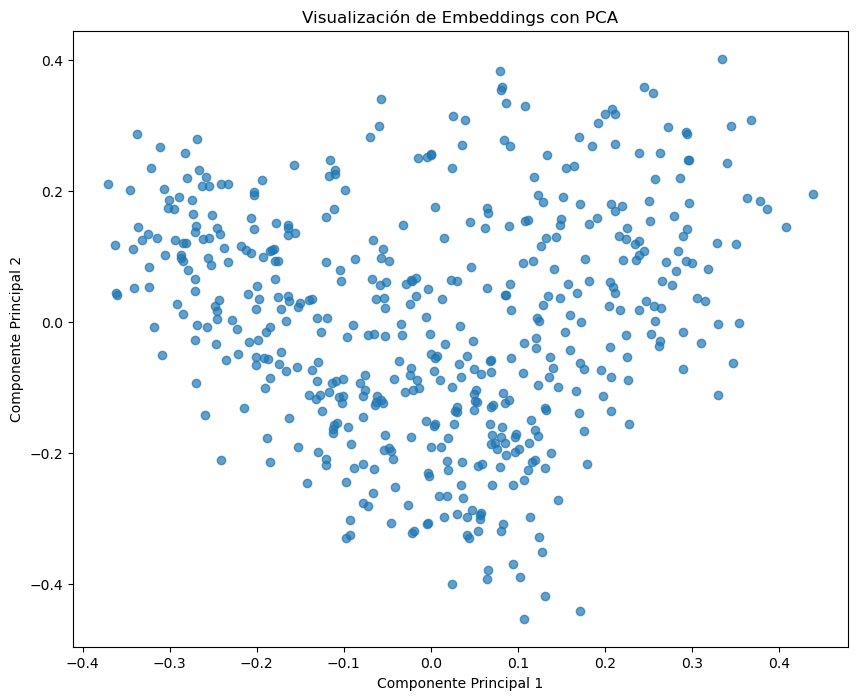

In [41]:
plt.figure(figsize=(10, 8))

plt.scatter(
    reduced_embeddings[:, 0],
    reduced_embeddings[:, 1],
    alpha=0.7
)

plt.title("Visualización de Embeddings con PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()